In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/dataset/dataset"

In [ ]:
print(os.path.exists(dataset_path))

True


## Check your digit folders

In [ ]:
print(os.listdir(dataset_path))

['3', '6', '7', '4', '2', '1', '8', '0', '9', '5']


##  Count images in every folder

In [ ]:
import os
import matplotlib.pyplot as plt

image_counts = []

for digit in range(10):

    folder = os.path.join(dataset_path, str(digit))

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp')
        )
    ]

    image_counts.append(len(files))

    print(f"Digit {digit}: {len(files)} images")

Digit 0: 80 images
Digit 1: 40 images
Digit 2: 80 images
Digit 3: 40 images
Digit 4: 80 images
Digit 5: 80 images
Digit 6: 69 images
Digit 7: 42 images
Digit 8: 42 images
Digit 9: 40 images


## Class imbalance check by Bargraph

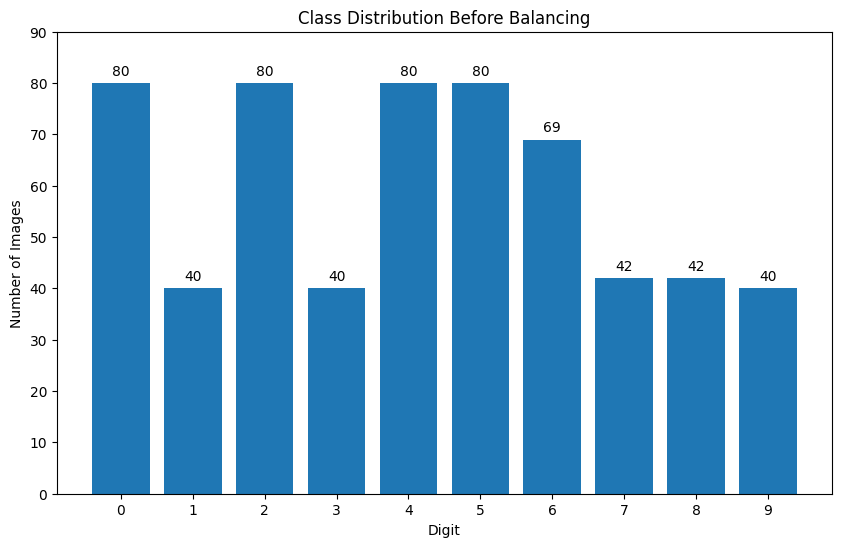

In [ ]:
digits = list(range(10))

plt.figure(figsize=(10, 6))

bars = plt.bar(digits, image_counts)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Class Distribution Before Balancing")

plt.xticks(digits)

# Show number on top of each bar
for bar, count in zip(bars, image_counts):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha='center',
        va='bottom'
    )

plt.ylim(0, max(image_counts) + 10)

plt.show()

## Randomly select 40 images per digit

In [ ]:
random.seed(42)

selected_images = {}

for digit in range(10):

    folder = os.path.join(dataset_path, str(digit))

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp')
        )
    ]

    if len(files) < 40:
        raise ValueError(
            f"Digit {digit} has only {len(files)} images."
        )

    selected_images[digit] = random.sample(files, 40)

    print(
        f"Digit {digit}: "
        f"{len(selected_images[digit])} selected"
    )

Digit 0: 40 selected
Digit 1: 40 selected
Digit 2: 40 selected
Digit 3: 40 selected
Digit 4: 40 selected
Digit 5: 40 selected
Digit 6: 40 selected
Digit 7: 40 selected
Digit 8: 40 selected
Digit 9: 40 selected


## STEP 9 — Display some RAW images

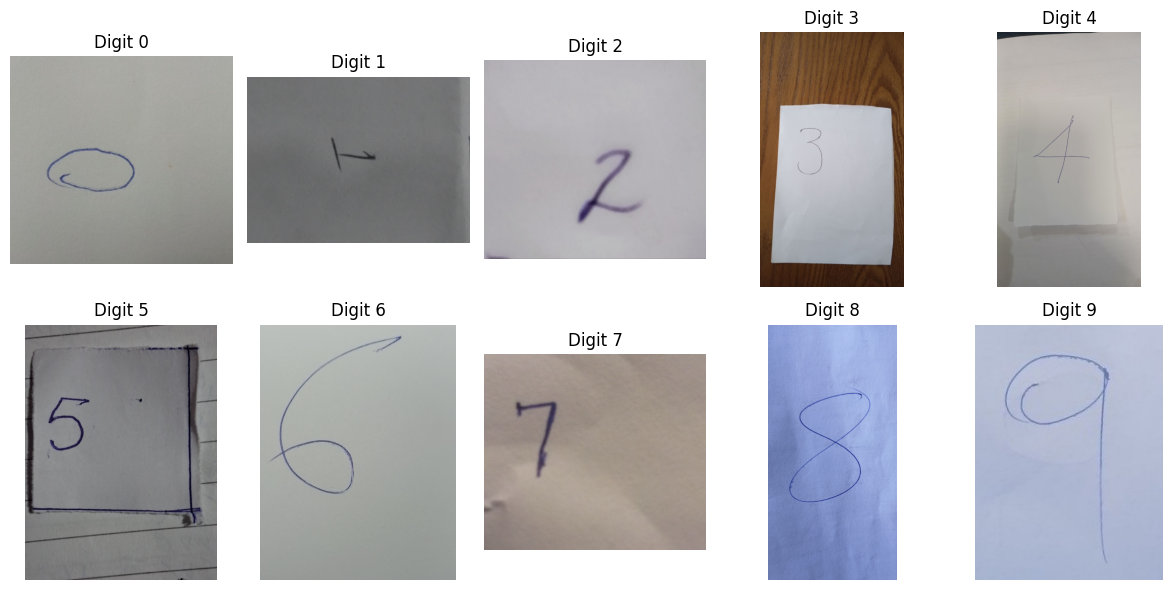

In [ ]:
plt.figure(figsize=(12, 6))

for digit in range(10):

    filename = selected_images[digit][0]

    image_path = os.path.join(
        dataset_path,
        str(digit),
        filename
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, digit + 1)
    plt.imshow(image)
    plt.title(f"Digit {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## STEP 10 — Quality control

In [ ]:
## Check is any corrupeted image exist
corrupted_images = []

for digit in range(10):

    for filename in selected_images[digit]:

        image_path = os.path.join(
            dataset_path,
            str(digit),
            filename
        )

        try:

            img = Image.open(image_path)
            img.verify()

        except:

            corrupted_images.append(image_path)

In [ ]:
print(
    "Number of corrupted images:",
    len(corrupted_images)
)

Number of corrupted images: 0


## STEP 11 — Create the preprocessing function


In [ ]:
# now we will start actual preprocessing
#Raw image-Grayscale-Threshold-Find digit-Crop-Center-Resize-Normalize-32x32x1

def preprocess_image(image_path):

    # -----------------------------
    # 1. Read image
    # -----------------------------
    image = cv2.imread(image_path)

    if image is None:
        return None

    # -----------------------------
    # 2. Convert to grayscale
    # -----------------------------
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------
    # 3. Threshold
    # -----------------------------
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # -----------------------------
    # 4. Find contours
    # -----------------------------
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    # -----------------------------
    # 5. Find largest contour
    # -----------------------------
    contour = max(
        contours,
        key=cv2.contourArea
    )

    # -----------------------------
    # 6. Get bounding box
    # -----------------------------
    x, y, w, h = cv2.boundingRect(contour)

    # -----------------------------
    # 7. Add margin
    # -----------------------------
    margin = 10

    x1 = max(0, x - margin)
    y1 = max(0, y - margin)

    x2 = min(
        binary.shape[1],
        x + w + margin
    )

    y2 = min(
        binary.shape[0],
        y + h + margin
    )

    cropped = binary[y1:y2, x1:x2]

    # -----------------------------
    # 8. Make image square
    # -----------------------------
    h, w = cropped.shape

    size = max(h, w)

    square = np.zeros(
        (size, size),
        dtype=np.uint8
    )

    x_offset = (size - w) // 2
    y_offset = (size - h) // 2

    square[
        y_offset:y_offset+h,
        x_offset:x_offset+w
    ] = cropped

    # -----------------------------
    # 9. Resize to 32 × 32
    # -----------------------------
    resized = cv2.resize(
        square,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )

    # -----------------------------
    # 10. Normalize to [0,1]
    # -----------------------------
    normalized = (
        resized.astype("float32") / 255.0
    )

    # -----------------------------
    # 11. Add channel dimension
    # -----------------------------
    normalized = np.expand_dims(
        normalized,
        axis=-1
    )

    return normalized

## STEP 12 — Test ONE image first

In [ ]:
test_filename = selected_images[7][0]

test_path = os.path.join(
    dataset_path,
    "7",
    test_filename
)

processed = preprocess_image(test_path)

In [ ]:
# check the processed image shape
print(processed.shape)

(32, 32, 1)


In [ ]:
print("Minimum:", processed.min())
print("Maximum:", processed.max())

Minimum: 0.0
Maximum: 1.0


## STEP 13 — Display processed image

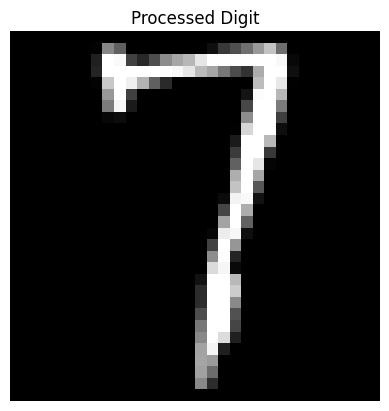

In [ ]:
plt.imshow(
    processed.squeeze(),
    cmap="gray"
)

plt.title("Processed Digit")
plt.axis("off")

plt.show()

## STEP 14 — Compare RAW vs PROCESSED

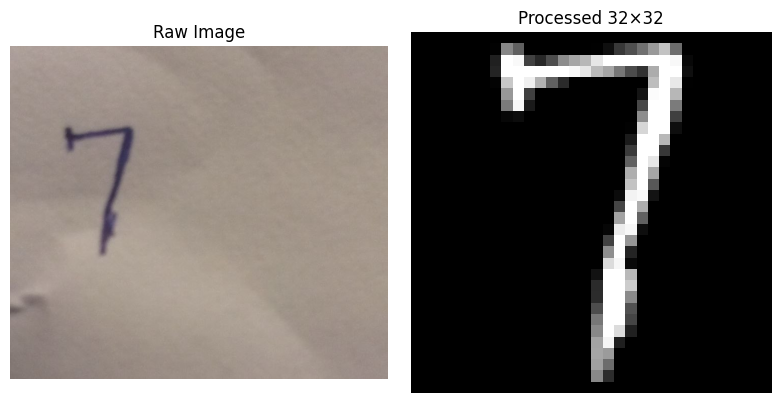

In [ ]:
raw = cv2.imread(test_path)

raw_rgb = cv2.cvtColor(
    raw,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 4))

# Raw
plt.subplot(1, 2, 1)
plt.imshow(raw_rgb)
plt.title("Raw Image")
plt.axis("off")

# Processed
plt.subplot(1, 2, 2)
plt.imshow(
    processed.squeeze(),
    cmap="gray"
)
plt.title("Processed 32×32")
plt.axis("off")

plt.tight_layout()
plt.show()

## STEP 15 — Process all 400 images

In [ ]:
X = []
y = []

for digit in range(10):

    print(f"Processing digit {digit}...")

    for filename in selected_images[digit]:

        image_path = os.path.join(
            dataset_path,
            str(digit),
            filename
        )

        processed = preprocess_image(
            image_path
        )

        if processed is not None:

            X.append(processed)
            y.append(digit)

Processing digit 0...
Processing digit 1...
Processing digit 2...
Processing digit 3...
Processing digit 4...
Processing digit 5...
Processing digit 6...
Processing digit 7...
Processing digit 8...
Processing digit 9...


In [ ]:
## Convert them to NumPy:
X = np.array(X)
y = np.array(y)


In [ ]:
## check the shape
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 32, 32, 1)
y shape: (400,)


## STEP 16 — Check class balance

In [ ]:
unique, counts = np.unique(
    y,
    return_counts=True
)

for digit, count in zip(unique, counts):

    print(
        f"Digit {digit}: {count} images"
    )

Digit 0: 40 images
Digit 1: 40 images
Digit 2: 40 images
Digit 3: 40 images
Digit 4: 40 images
Digit 5: 40 images
Digit 6: 40 images
Digit 7: 40 images
Digit 8: 40 images
Digit 9: 40 images


## STEP 17 — Train / Validation / Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [ ]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (256, 32, 32, 1)
Validation: (64, 32, 32, 1)
Testing: (80, 32, 32, 1)


## STEP 18 — Create augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
# For handwritten digits, don't make augmentation too aggressive.
data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.10),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    )
])

## STEP 20 — Visualize augmentation

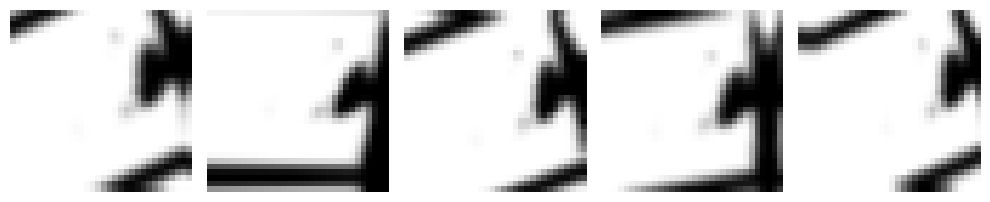

In [ ]:
sample_image = X_train[0]

plt.figure(figsize=(10, 4))

for i in range(5):

    augmented = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        augmented[0].numpy().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# CNN TRAINING PHASE

# Step 1 — Import TensorFlow/Keras

In [ ]:
import tensorflow as tf

from tensorflow.keras import layers, models


In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
## Check data set
print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training data: (256, 32, 32, 1)
Validation data: (64, 32, 32, 1)
Test data: (80, 32, 32, 1)
Training labels: (256,)
Validation labels: (64,)
Test labels: (80,)


## STEP 3 — Understand the CNN

In [ ]:
#Input(32×32×1)--Conv2D--ReLu-MaxPooling_Conv2D--ReLu-MaxPooling-Flatten-Dense-Softmax-10 classes

# STEP 4 — Create the CNN

In [ ]:
model = models.Sequential([

    # Input image
    layers.Input(shape=(32, 32, 1)),

    # First convolution
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Downsampling
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolution
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Downsampling
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        64,
        activation='relu'
    ),

    # Output layer
    layers.Dense(
        10,
        activation='softmax'
    )
])

## STEP 6 — Look at your model

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,986 (652.29 KB)

 Trainable params: 166,986 (652.29 KB)

 Non-trainable params: 0 (0.00 B)

## STEP 7 — Compile the CNN

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## STEP 8 — Train the CNN WITHOUT augmentation first

In [ ]:
history_baseline = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=20,
    batch_size=16
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.2461 - loss: 2.1559 - val_accuracy: 0.3906 - val_loss: 1.9599
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4648 - loss: 1.7293 - val_accuracy: 0.3906 - val_loss: 1.7051
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5586 - loss: 1.3874 - val_accuracy: 0.5000 - val_loss: 1.6661
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6523 - loss: 1.1450 - val_accuracy: 0.4531 - val_loss: 1.7006
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6758 - loss: 1.0228 - val_accuracy: 0.5000 - val_loss: 1.5930
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7188 - loss: 0.8626 - val_accuracy: 0.5312 - val_loss: 1.7178
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7266 - loss: 0.7970 - val_accuracy: 0.6094 - val_loss: 1.5625
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7812 - loss: 0.6731 - val_accuracy: 0.5312 - v

## STEP 11 — Plot training accuracy

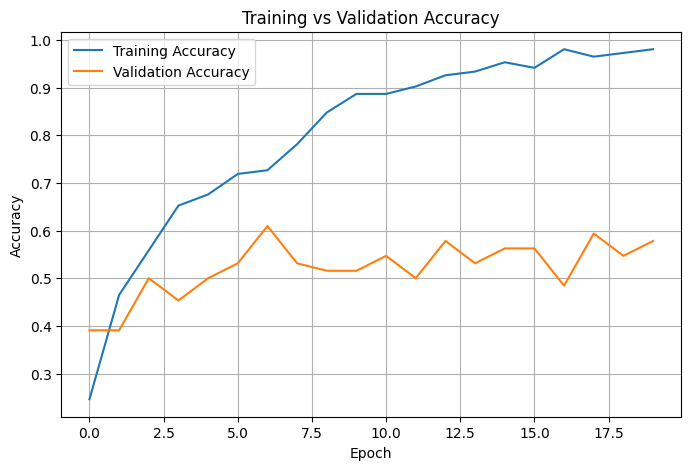

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## STEP 12 — Plot training and validation loss

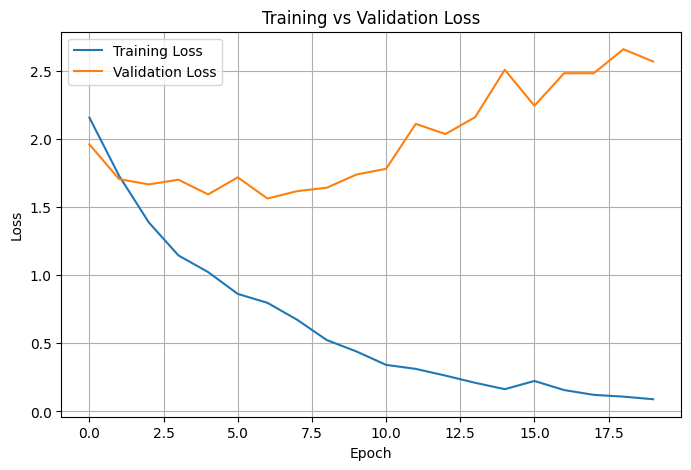

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_baseline.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## STEP 13 — Evaluate on the untouched test set

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 2.0592 


In [ ]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 2.059208631515503
Test Accuracy: 0.5625


## STEP 14 — Make predictions

In [ ]:
y_probability = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [ ]:
y_pred = np.argmax(
    y_probability,
    axis=1
)

In [ ]:
print("Actual:", y_test[:10])
print("Predicted:", y_pred[:10])

Actual: [6 5 3 4 7 6 6 9 4 8]
Predicted: [6 9 5 2 7 0 0 9 7 2]


## STEP 15 — Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4 3 0 0 0 0 0 0 0 1]
 [0 5 2 0 0 1 0 0 0 0]
 [1 1 4 0 2 0 0 0 0 0]
 [0 0 0 7 0 1 0 0 0 0]
 [0 1 2 1 2 0 0 1 0 1]
 [1 0 2 0 0 4 0 0 0 1]
 [2 1 0 0 0 0 5 0 0 0]
 [2 0 2 0 0 0 0 4 0 0]
 [0 0 1 0 0 0 1 0 5 1]
 [0 0 0 0 0 3 0 0 0 5]]


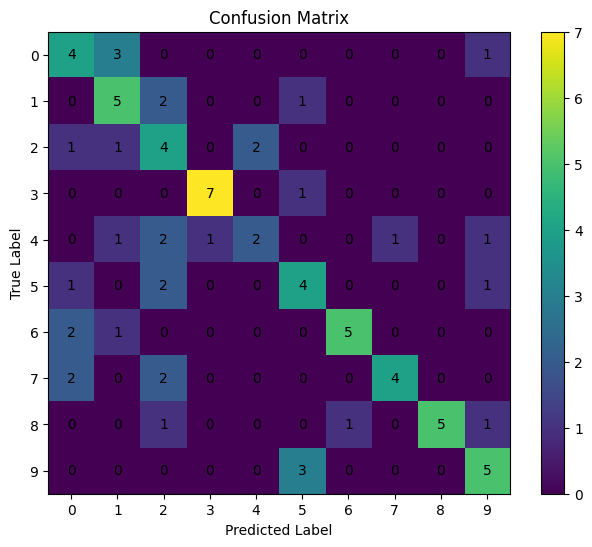

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):

    for j in range(10):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

## STEP 16 — Classification report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.40      0.50      0.44         8
           1       0.45      0.62      0.53         8
           2       0.31      0.50      0.38         8
           3       0.88      0.88      0.88         8
           4       0.50      0.25      0.33         8
           5       0.44      0.50      0.47         8
           6       0.83      0.62      0.71         8
           7       0.80      0.50      0.62         8
           8       1.00      0.62      0.77         8
           9       0.56      0.62      0.59         8

    accuracy                           0.56        80
   macro avg       0.62      0.56      0.57        80
weighted avg       0.62      0.56      0.57        80



### STEP 17 — Display correct and incorrect predictions

In [ ]:
incorrect = np.where(
    y_pred != y_test
)[0]

print(
    "Number of incorrect predictions:",
    len(incorrect)
)

Number of incorrect predictions: 35


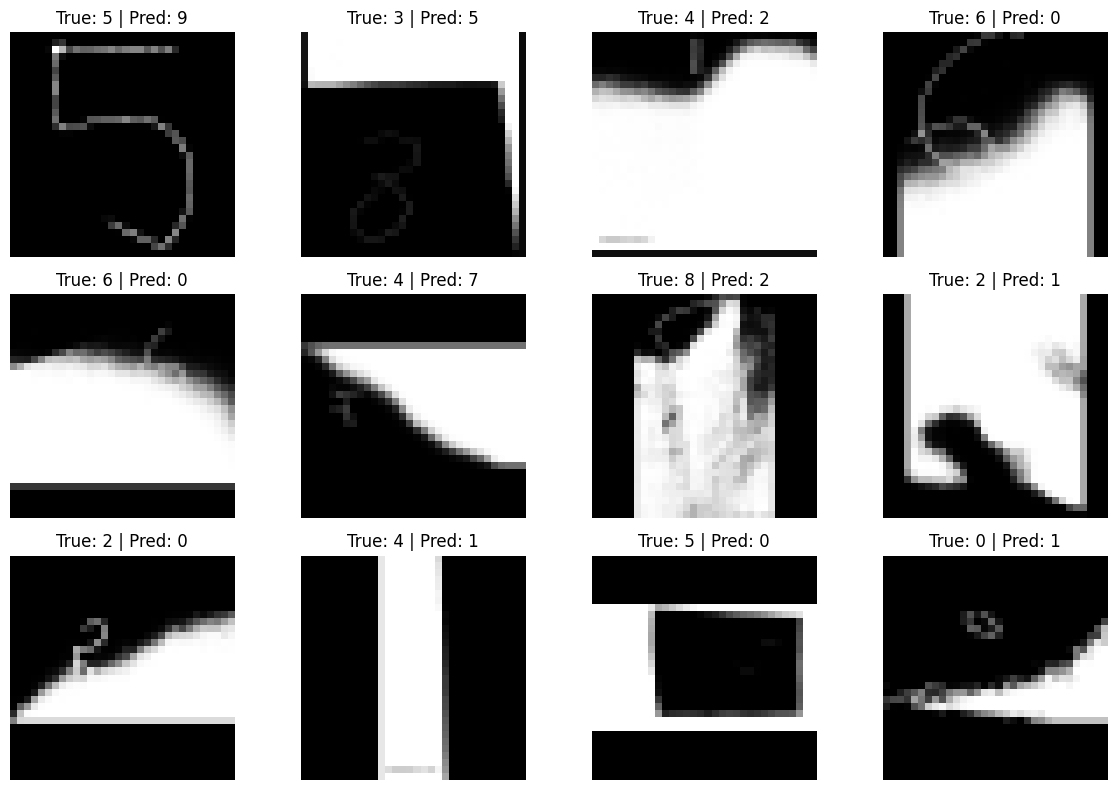

In [ ]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect[:12]):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {y_test[index]} | "
        f"Pred: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## STEP 18 — Now train with augmentation

In [ ]:
history_augmented = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=16,

    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9961 - loss: 0.0402 - val_accuracy: 0.5625 - val_loss: 2.8712
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9883 - loss: 0.0421 - val_accuracy: 0.5625 - val_loss: 2.7988
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9883 - loss: 0.0359 - val_accuracy: 0.5469 - val_loss: 2.9683
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9883 - loss: 0.0616 - val_accuracy: 0.5625 - val_loss: 3.1331
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9883 - loss: 0.0332 - val_accuracy: 0.5938 - val_loss: 3.1803
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9883 - loss: 0.1247 - val_accuracy: 0.5156 - val_loss: 3.0673
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9844 - loss: 0.0536 - val_accuracy: 0.5781 - val_loss: 3.0577


## STEP 19 — Create CNN + augmentation

In [ ]:
model_aug = models.Sequential([

    layers.Input(shape=(32, 32, 1)),

    # Augmentation - training only
    data_augmentation,

    # CNN
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

In [ ]:
# Compile
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
## Train
history = model_aug.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=16,

    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.1641 - loss: 2.2589 - val_accuracy: 0.2812 - val_loss: 2.0782
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3086 - loss: 2.0403 - val_accuracy: 0.3906 - val_loss: 1.8673
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3867 - loss: 1.8392 - val_accuracy: 0.2969 - val_loss: 1.8758
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4414 - loss: 1.7206 - val_accuracy: 0.4062 - val_loss: 1.7622
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4297 - loss: 1.6993 - val_accuracy: 0.3906 - val_loss: 1.5974
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4258 - loss: 1.6180 - val_accuracy: 0.4688 - val_loss: 1.5319
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5117 - loss: 1.5217 - val_accuracy: 0.4688 - val_loss: 1.5915
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5234 - loss: 1.4786 - val_accuracy: 0.5156 - v

## STEP 20 — Evaluate the final augmented CNN

In [ ]:
test_loss, test_accuracy = model_aug.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy:.4f}"
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6500 - loss: 1.1429 
Final Test Accuracy: 0.6500


## STEP 21 — Compare baseline vs augmented model

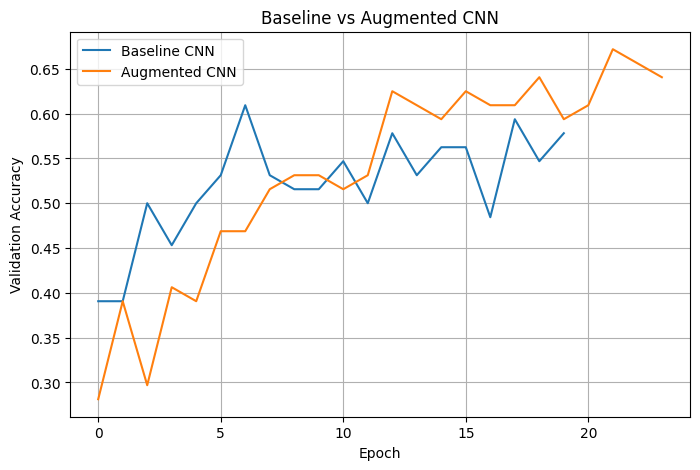

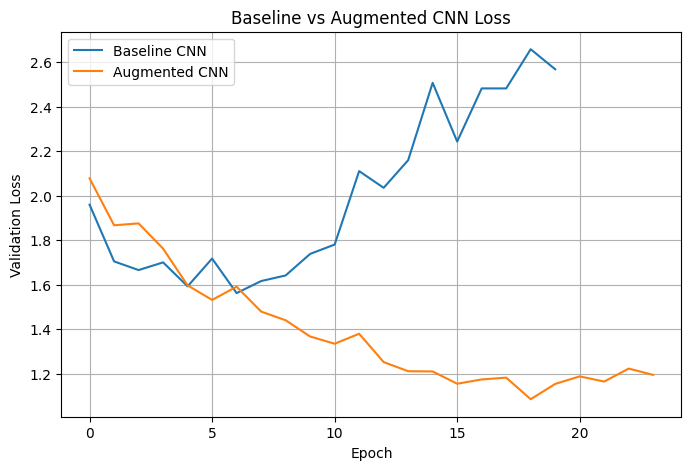

In [ ]:
import matplotlib.pyplot as plt

# Compare Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline CNN'
)

plt.plot(
    history.history['val_accuracy'],
    label='Augmented CNN'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Augmented CNN')
plt.legend()
plt.grid(True)
plt.show()


# Compare Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history['val_loss'],
    label='Baseline CNN'
)

plt.plot(
    history.history['val_loss'],
    label='Augmented CNN'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Baseline vs Augmented CNN Loss')
plt.legend()
plt.grid(True)
plt.show()

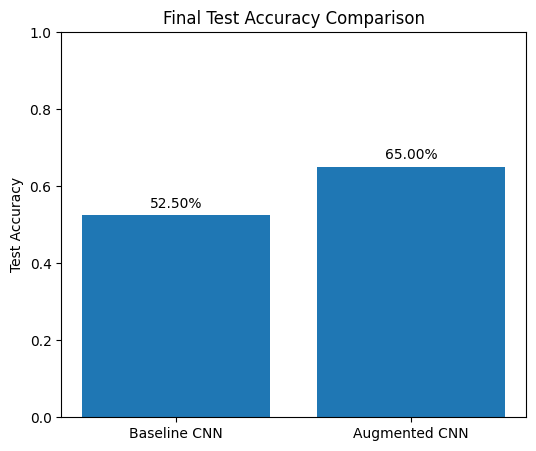

In [ ]:
baseline_acc = model.evaluate(X_test, y_test, verbose=0)[1]
augmented_acc = model_aug.evaluate(X_test, y_test, verbose=0)[1]

plt.figure(figsize=(6, 5))

plt.bar(
    ['Baseline CNN', 'Augmented CNN'],
    [baseline_acc, augmented_acc]
)

plt.ylabel('Test Accuracy')
plt.title('Final Test Accuracy Comparison')
plt.ylim(0, 1)

for i, value in enumerate([baseline_acc, augmented_acc]):
    plt.text(i, value + 0.02, f'{value:.2%}', ha='center')

plt.show()

Saving photo_2026-08-25_21-02-42.jpg to photo_2026-08-25_21-02-42.jpg


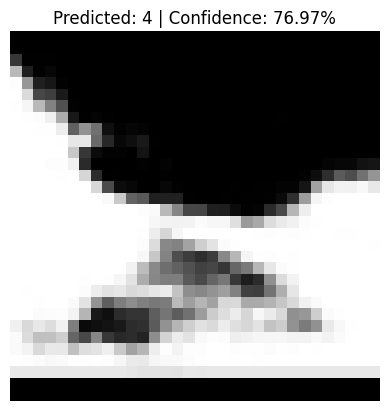

In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Preprocess
img = preprocess_image(image_path)

# Predict
prediction = model_aug.predict(
    np.expand_dims(img, axis=0),
    verbose=0
)

digit = np.argmax(prediction[0])
confidence = np.max(prediction[0])

# Show result
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Predicted: {digit} | Confidence: {confidence:.2%}")
plt.axis("off")
plt.show()

## STEP 22 — Save final model

In [ ]:
model_aug.save(
    "/content/handwritten_digit_cnn.keras"
)

In [ ]:
from google.colab import files

files.download("/content/handwritten_digit_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>